# import  libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data/diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
df.shape

(768, 9)

In [4]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe

<bound method NDFrame.describe of      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627  

In [9]:

df = df[df['Glucose'] != 0]
df = df[df['BloodPressure'] != 0]
df = df[df['BMI'] != 0]
heavy_missing_cols = ['SkinThickness', 'Insulin']
df[heavy_missing_cols] = df[heavy_missing_cols].replace(0, np.nan)
for col in heavy_missing_cols:
    df[col] = df[col].fillna(df[col].median())
print("Final Cleaned Data Size:", df.shape)

Final Cleaned Data Size: (724, 9)


In [10]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,724.000000,724.000000,724.000000,724.000000,724.000000,724.000000,724.000000,724.000000,724.000000
mean,3.866022,121.882597,72.400552,29.133978,142.044199,32.467127,0.474765,33.350829,0.343923
std,3.362803,30.750030,12.379870,9.019267,88.713438,6.888941,0.332315,11.765393,0.475344
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,118.250000,27.500000,0.245000,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.500000,32.400000,0.379000,29.000000,0.000000
75%,6.000000,142.000000,80.000000,33.000000,130.500000,36.600000,0.627500,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# count plot

C:\Users\prime\AppData\Local\Temp\ipykernel_6332\1949101065.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df, palette='Set2')


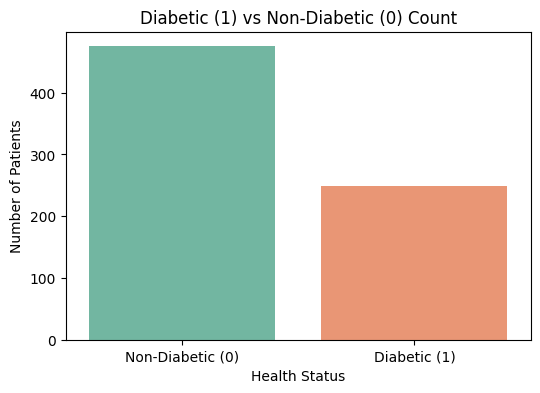

In [11]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df, palette='Set2')
plt.title('Diabetic (1) vs Non-Diabetic (0) Count')
plt.xlabel('Health Status')
plt.ylabel('Number of Patients')
plt.xticks([0, 1], ['Non-Diabetic (0)', 'Diabetic (1)'])
plt.show()

# Check  Histograms

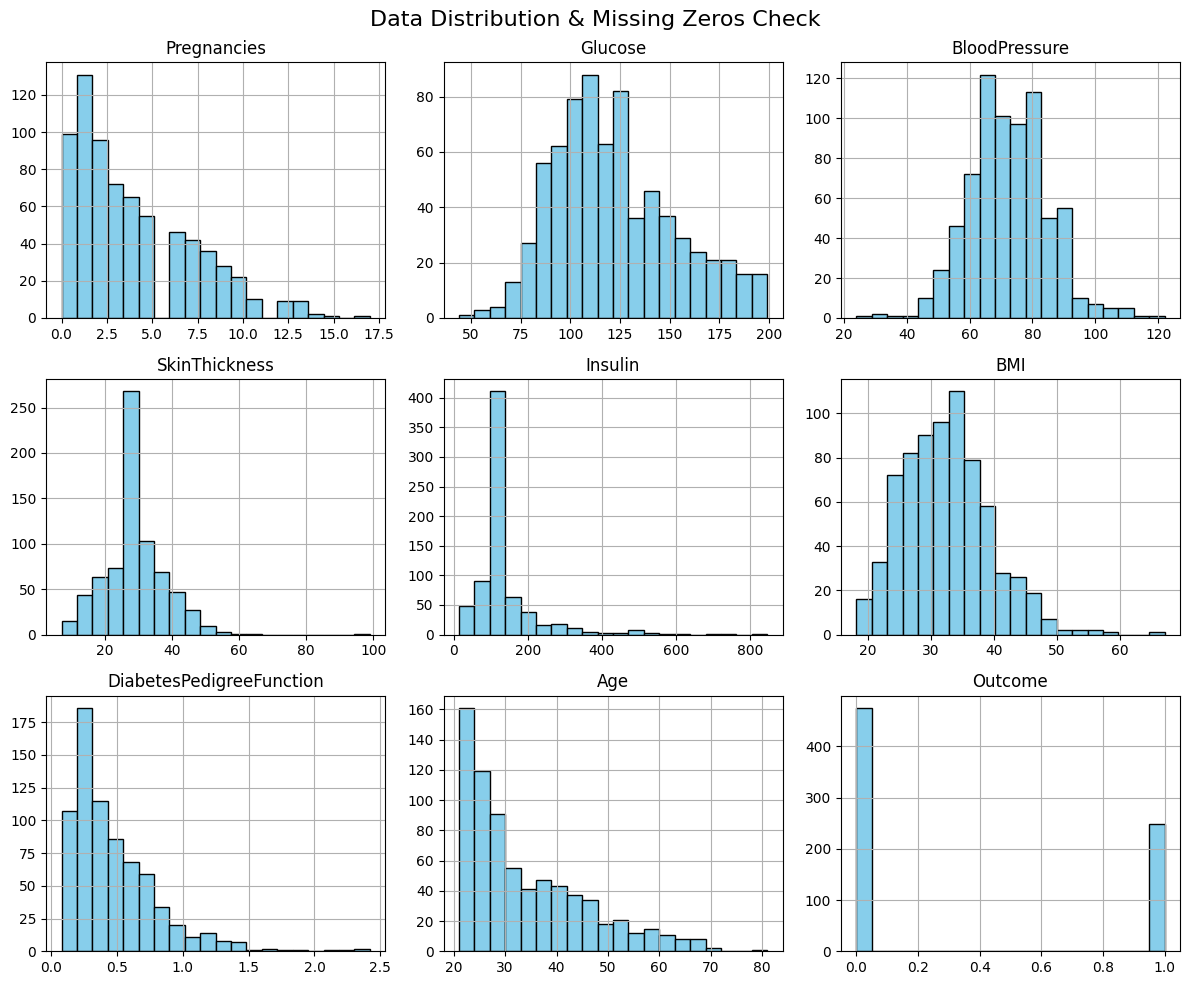

In [12]:
df.hist(figsize=(12, 10), bins=20, color='skyblue', edgecolor='black')
plt.suptitle('Data Distribution & Missing Zeros Check', fontsize=16)
plt.tight_layout()
plt.show()

In [13]:
columns_to_check = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("Columns mein total kitne '0' values hain:")
for col in columns_to_check:
    zero_count = (df[col] == 0).sum()
    print(f"- {col}: {zero_count} zeros")

Columns mein total kitne '0' values hain:
- Glucose: 0 zeros
- BloodPressure: 0 zeros
- SkinThickness: 0 zeros
- Insulin: 0 zeros
- BMI: 0 zeros


In [14]:
columns_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in columns_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].replace(0, np.nan)
    col_median = df[col].median()
    df[col] = df[col].fillna(col_median)
print("--- Verification Check ---")
print("Again check zeros:")
for col in columns_to_fix:
    zero_count = (df[col] == 0).sum()
    print(f"- {col}: {zero_count} zeros (corrected!)")

--- Verification Check ---
Again check zeros:
- Glucose: 0 zeros (corrected!)
- BloodPressure: 0 zeros (corrected!)
- SkinThickness: 0 zeros (corrected!)
- Insulin: 0 zeros (corrected!)
- BMI: 0 zeros (corrected!)


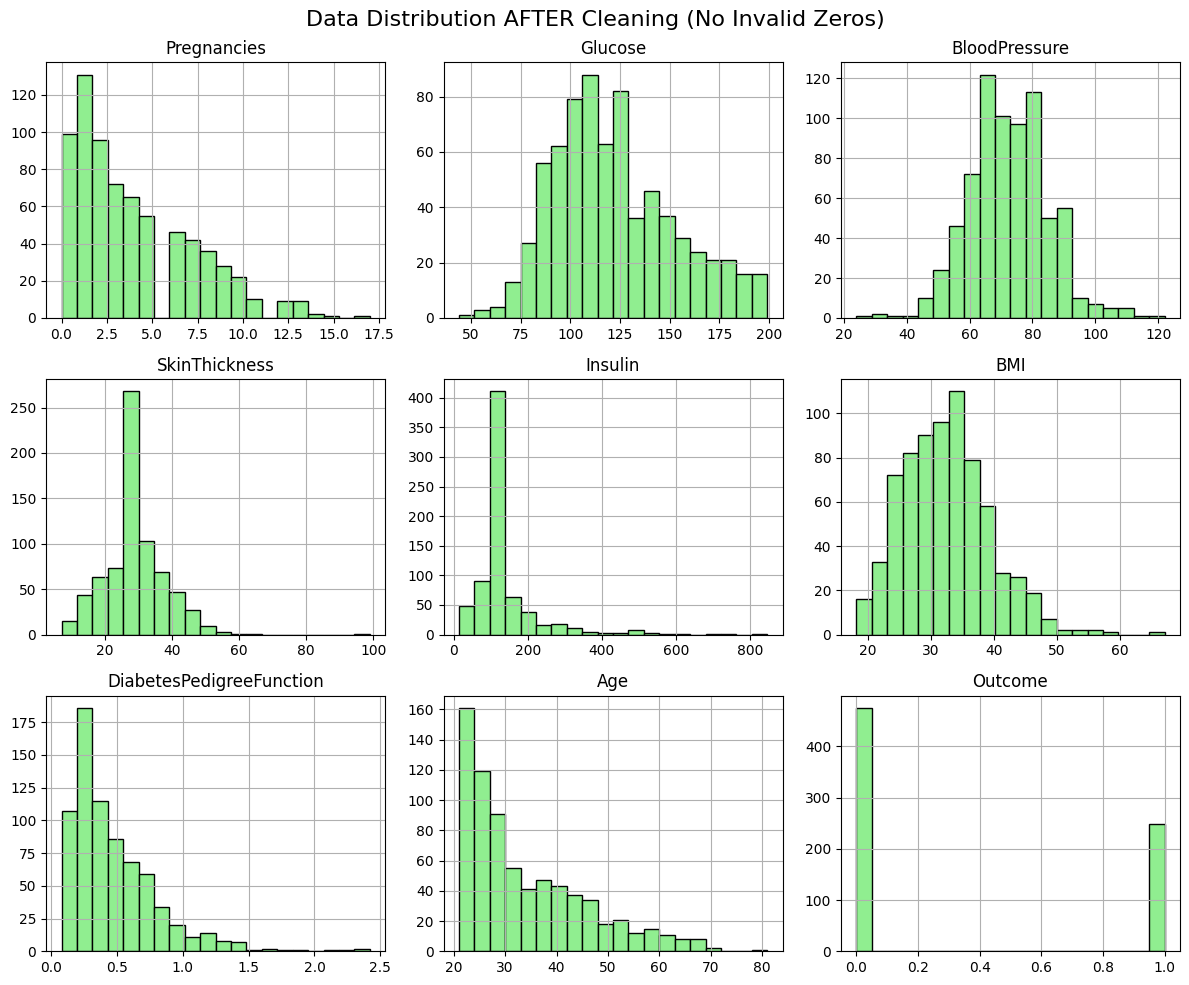

In [15]:
# Cleaned data ka histogram check karne ke liye code
df.hist(figsize=(12, 10), bins=20, color='lightgreen', edgecolor='black')
plt.suptitle('Data Distribution AFTER Cleaning (No Invalid Zeros)', fontsize=16)
plt.tight_layout()
plt.show()

# check boxplot

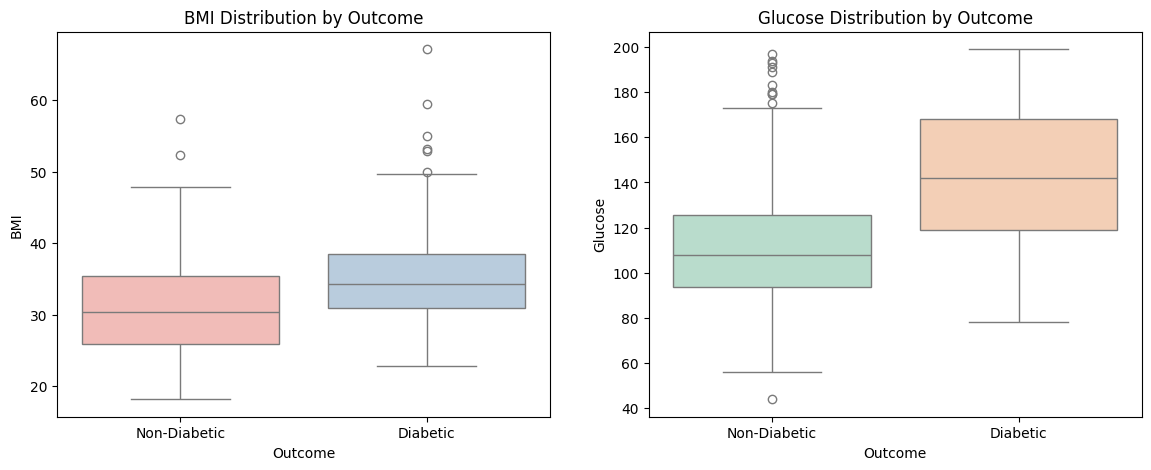

In [16]:
import warnings
warnings.filterwarnings('ignore') 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(ax=axes[0], x='Outcome', y='BMI', data=df, palette='Pastel1')
axes[0].set_title('BMI Distribution by Outcome')
axes[0].set_xticklabels(['Non-Diabetic', 'Diabetic'])
sns.boxplot(ax=axes[1], x='Outcome', y='Glucose', data=df, palette='Pastel2')
axes[1].set_title('Glucose Distribution by Outcome')
axes[1].set_xticklabels(['Non-Diabetic', 'Diabetic'])

plt.show()

# check corelation Heatmap

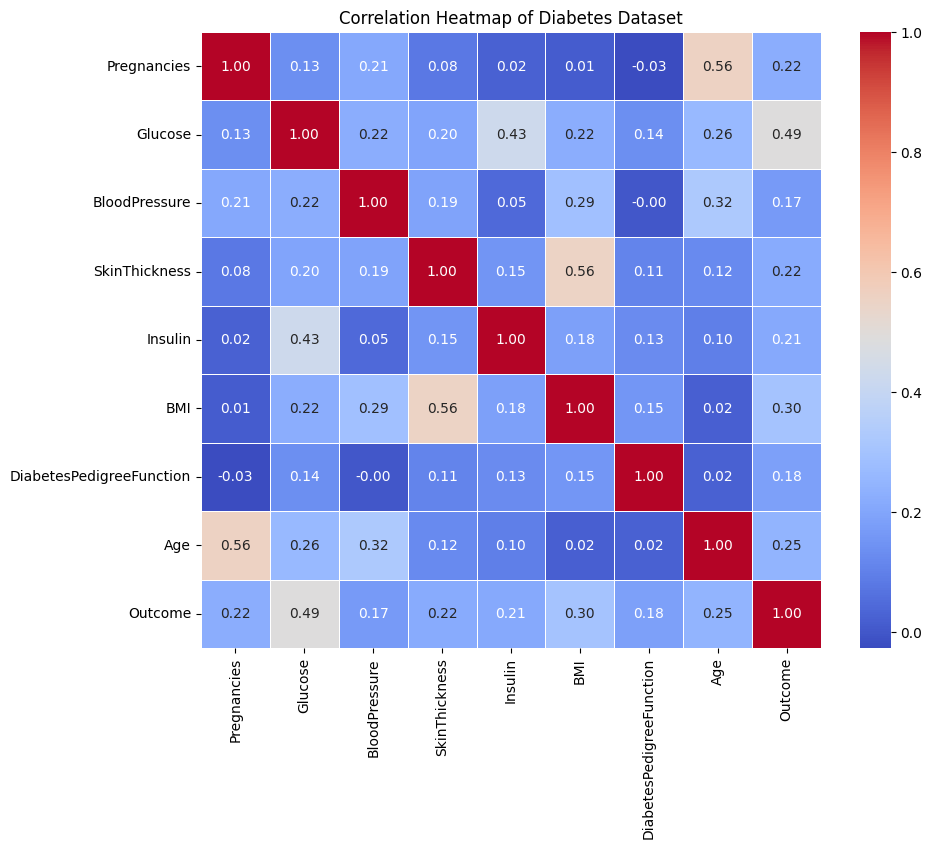

In [17]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Diabetes Dataset')
plt.show()

# Dtaa Preprocessing

In [18]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

In [21]:
from sklearn.preprocessing import StandardScaler

In [22]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model Training

In [23]:
from sklearn.linear_model import LogisticRegression

In [24]:
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [25]:
y_pred = model.predict(X_test)

In [26]:
from sklearn.metrics import accuracy_score, classification_report
print(" Model Accuracy Score:", accuracy_score(y_test, y_pred) * 100)
print("\nDetailed Performance Report:\n", classification_report(y_test, y_pred))

 Model Accuracy Score: 79.3103448275862

Detailed Performance Report:
               precision    recall  f1-score   support

           0       0.85      0.86      0.85       102
           1       0.66      0.63      0.64        43

    accuracy                           0.79       145
   macro avg       0.75      0.75      0.75       145
weighted avg       0.79      0.79      0.79       145



# Model Evaluation

In [27]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [28]:
accuracy_score(y_test, y_pred)

0.7931034482758621

In [29]:
confusion_matrix(y_test, y_pred)

array([[88, 14],
       [16, 27]])

In [30]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.86      0.85       102
           1       0.66      0.63      0.64        43

    accuracy                           0.79       145
   macro avg       0.75      0.75      0.75       145
weighted avg       0.79      0.79      0.79       145



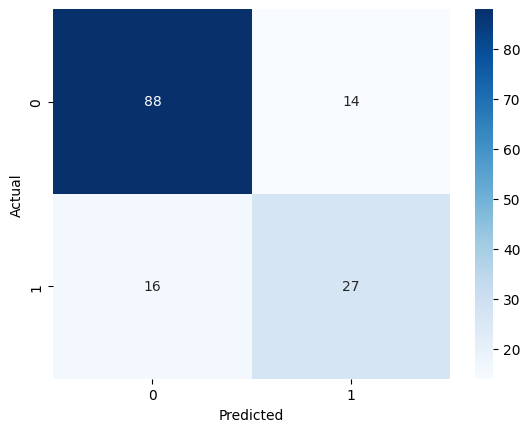

In [31]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Prediction System

In [32]:
input_data = [[2, 120, 70, 20, 85, 28.5, 0.5, 30]]
input_data_scaled = scaler.transform(input_data)
prediction = model.predict(input_data_scaled)
print("Model Output Array:", prediction)

Model Output Array: [0]


In [33]:
# Check prediction condition
if prediction[0] == 0:
    print(" Result: Person is Non-Diabetic")
else:
    print(" Result: Person is Diabetic")

 Result: Person is Non-Diabetic


# Save Model

In [34]:
import joblib

In [35]:
joblib.dump(model, 'models/diabetes_model.pkl')

['models/diabetes_model.pkl']

In [36]:
joblib.dump(scaler, 'models/scaler.pkl')

['models/scaler.pkl']

In [37]:
# Cleaned DataFrame ko 'data' folder ke andar save karne ke liye
df.to_csv('data/cleaned_diabetes.csv', index=False)